In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("dataset"):
    for file in files:
        print(os.path.join(root, file))

dataset/Housing.csv


In [ ]:
import pandas as pd

df = pd.read_csv("dataset/Housing.csv")

print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(545, 13)


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 13)
(109, 13)


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 25349381423104.0000 - mae: 4727422.0000 - val_loss: 24781577519104.0000 - val_mae: 4623895.0000
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 25349337382912.0000 - mae: 4727416.5000 - val_loss: 24781493633024.0000 - val_mae: 4623886.5000
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25349186387968.0000 - mae: 4727402.0000 - val_loss: 24781225197568.0000 - val_mae: 4623860.5000
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 25348731305984.0000 - mae: 4727357.5000 - val_loss: 24780451348480.0000 - val_mae: 4623784.5000
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 25347517054976.0000 - mae: 4727239.5000 - val_loss: 24778480025600.0000 - val_mae: 4623596.5000
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 25344446824448.0000 - mae: 4726950.5000 - val_loss: 24773931302912.0000 - val_mae: 4623168.5000
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 25338

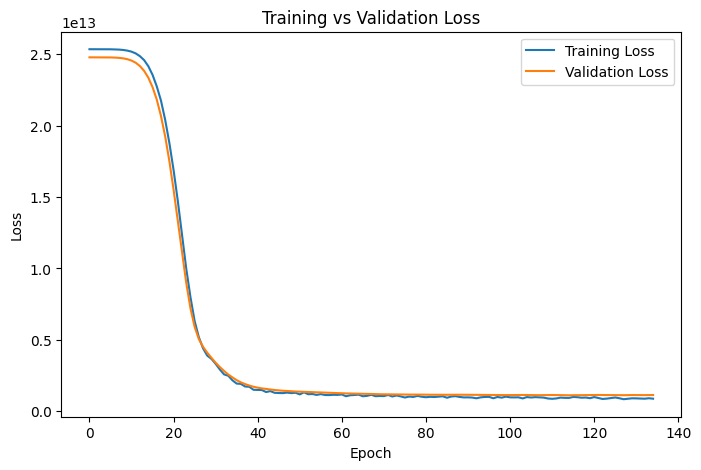

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)

Mean Absolute Error : 1048697.625
Mean Squared Error  : 1938426298368.0
Root Mean Squared Error : 1392273.7871438935


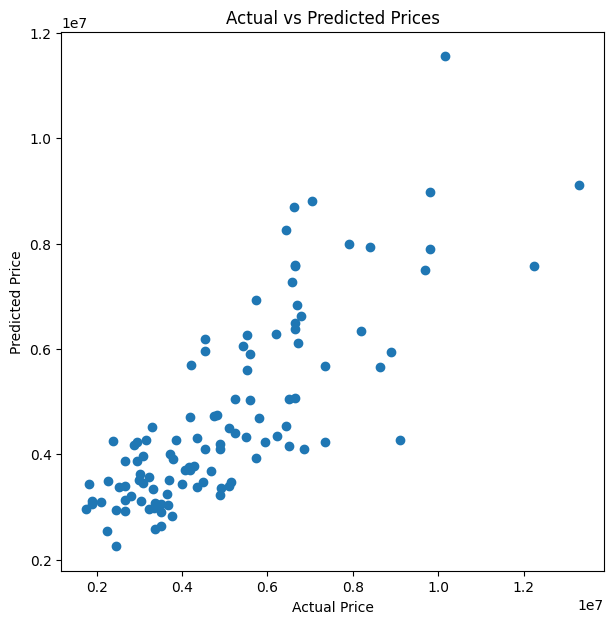

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

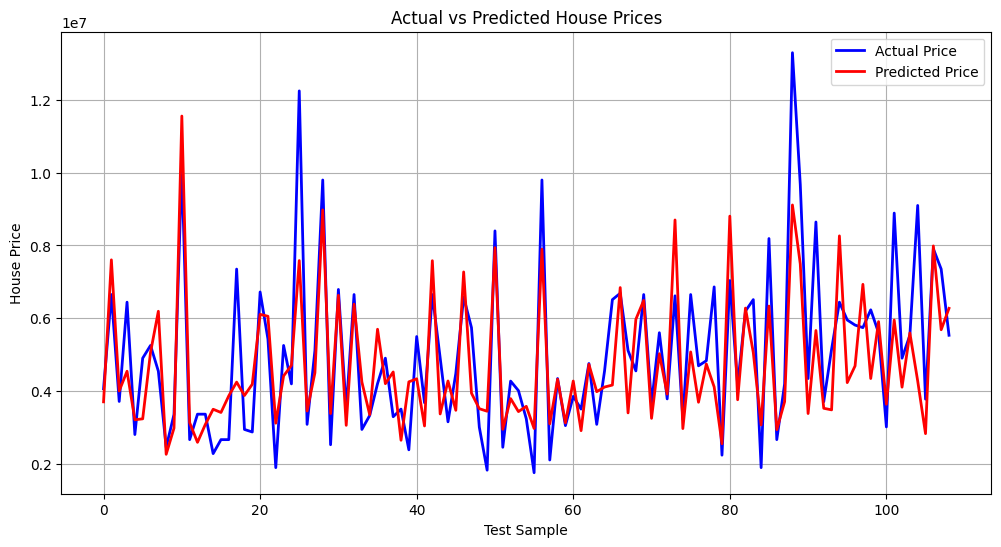

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten predictions
predictions = predictions.flatten()

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=2)
plt.plot(predictions, label='Predicted Price', color='red', linewidth=2)

plt.title('Actual vs Predicted House Prices')
plt.xlabel('Test Sample')
plt.ylabel('House Price')
plt.legend()
plt.grid(True)

plt.show()

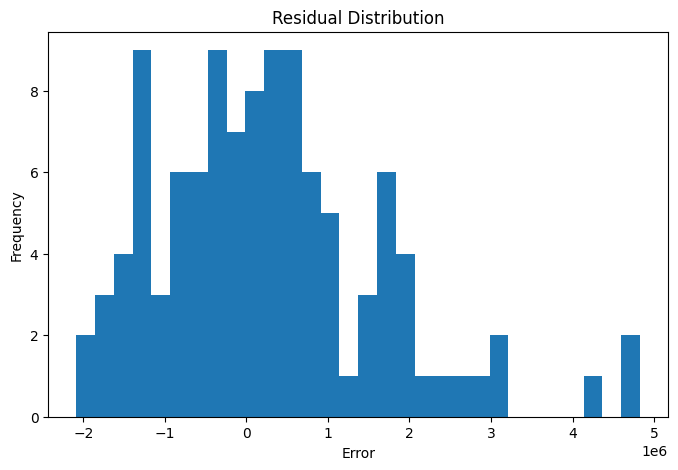

In [ ]:
residuals = y_test - predictions.flatten()

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(hidden_layers):

    model = Sequential()

    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(X_train.shape[1],)))

    for neurons in hidden_layers[1:]:
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(optimizer='adam',
                  loss='mse',
                  metrics=['mae'])

    return model

In [ ]:
architectures = {
    "2 Layers": [128, 64],
    "3 Layers": [256, 128, 64],
    "4 Layers": [256, 128, 64, 32],
    "5 Layers": [512, 256, 128, 64, 32],
    "6 Layers": [512, 256, 128, 64, 32, 16]
}

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results = []

for name, layers in architectures.items():

    print(f"\nTraining {name}")

    model = build_model(layers)

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    pred = model.predict(X_test, verbose=0)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    results.append([name, mae, mse, rmse])

results = pd.DataFrame(
    results,
    columns=["Architecture", "MAE", "MSE", "RMSE"]
)

results


Training 2 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training 3 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training 4 Layers

Training 5 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training 6 Layers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Architecture,MAE,MSE,RMSE
0,2 Layers,4914820.000,2.887081e+13,5.373156e+06
1,3 Layers,1292326.625,2.656618e+12,1.629914e+06
2,4 Layers,1060579.750,2.015957e+12,1.419844e+06
3,5 Layers,1031621.750,1.975682e+12,1.405590e+06
4,6 Layers,1058225.875,2.050815e+12,1.432067e+06


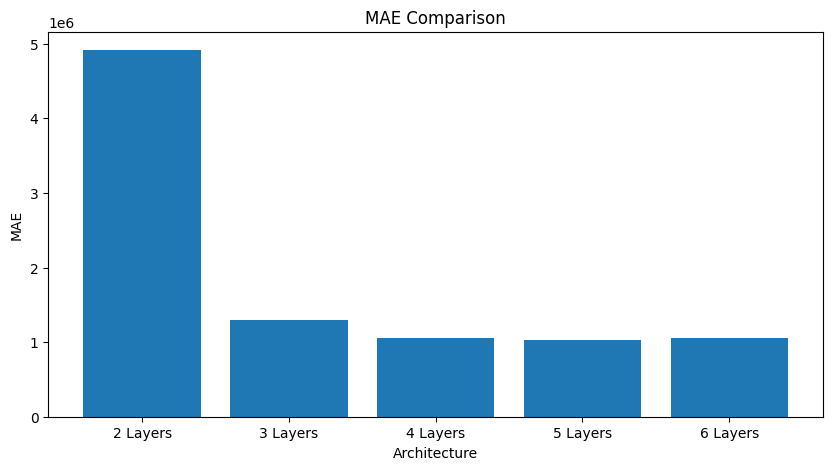

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(results["Architecture"], results["MAE"])

plt.title("MAE Comparison")

plt.xlabel("Architecture")

plt.ylabel("MAE")

plt.show()